# 06 — Evaluasi Final Untouched Test

Notebook ini menjalankan satu paket evaluasi final pada test month 7 setelah seluruh keputusan pengembangan dibekukan. Tidak ada training, fitting calibrator, pemilihan model, pemilihan threshold, atau perubahan risk band pada fase ini.

Eksekusi pertama menulis freeze manifest sebelum test dibuka. Eksekusi berikutnya memuat hasil tersimpan tanpa mengevaluasi test ulang. Score hanya digunakan untuk prioritas review manual dan tidak mengizinkan automated rejection.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from fraudshield.config import load_config, resolve_project_path
from fraudshield.final_evaluate import (
    run_phase6_final_evaluation,
    sha256_file,
)

CONFIG_PATH = Path("../configs/base.yaml")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Preflight artifact dan kebijakan terkunci

Cell ini hanya membaca konfigurasi serta menghitung hash artifact Fase 5. Dataset test belum dibuka.

In [2]:
config = load_config(CONFIG_PATH)
final_config = config["final_evaluation"]
phase5_artifact_keys = {
    "model": "phase5_model_artifact",
    "metadata": "phase5_metadata_artifact",
    "metrics": "phase5_metrics_artifact",
    "decision": "phase5_decision_artifact",
    "capacity_policy": "phase5_capacity_artifact",
    "risk_band_policy": "phase5_risk_band_artifact",
}
phase5_artifact_rows = []

for artifact_name, config_key in phase5_artifact_keys.items():
    artifact_path = resolve_project_path(
        final_config[config_key],
        config_path=CONFIG_PATH,
    )
    assert artifact_path.is_file(), f"Artifact Fase 5 tidak ditemukan: {artifact_path}"
    phase5_artifact_rows.append(
        {
            "artifact": artifact_name,
            "path": str(artifact_path),
            "sha256": sha256_file(artifact_path),
        }
    )

locked_policy = pd.Series(
    {
        "evaluation_periods": final_config["evaluation_periods"],
        "completed_result_policy": final_config["completed_result_policy"],
        "review_capacity": config["review_policy"]["capacity_rate"],
        "bootstrap_method": final_config["bootstrap"]["method"],
        "bootstrap_resamples": final_config["bootstrap"]["number_of_resamples"],
        "confidence_level": final_config["bootstrap"]["confidence_level"],
        "automated_rejection_allowed": config["review_policy"]["automated_rejection_allowed"],
    },
    name="nilai_terkunci",
)

assert final_config["evaluation_periods"] == config["split"]["test_periods"]
assert config["review_policy"]["automated_rejection_allowed"] is False
display(pd.DataFrame(phase5_artifact_rows))
display(locked_policy.to_frame())

,artifact,path,sha256
0,model,D:\latihan\fraudshield\artifacts\phase5\calibr...,23e59ddb6379608247bfa27f03c8a3e119639313edf005...
1,metadata,D:\latihan\fraudshield\artifacts\phase5\phase5...,9934c480f39274f3766d25aef8a00e39adc12a4efa6699...
2,metrics,D:\latihan\fraudshield\artifacts\phase5\calibr...,7d245289bd3db86e98b51552ddf7ea32f9acee955d2ebf...
3,decision,D:\latihan\fraudshield\artifacts\phase5\calibr...,800e4369613080f0a21d3e33436162eaae0185681d3c21...
4,capacity_policy,D:\latihan\fraudshield\artifacts\phase5\capaci...,027e9a4dff9b3bc335b8ed34c870d126dceb8142fb02a5...
5,risk_band_policy,D:\latihan\fraudshield\artifacts\phase5\risk_b...,1940f5f8e38d4e7532f642f125efaa6ed5e2fc96c173ca...


,nilai_terkunci
evaluation_periods,[7]
completed_result_policy,reuse_without_test_re_evaluation
review_capacity,0.05
bootstrap_method,stratified_percentile
bootstrap_resamples,200
confidence_level,0.95
automated_rejection_allowed,False


## 2. Jalankan atau muat evaluasi final

Menjalankan cell berikut untuk pertama kali berarti membuka month 7 setelah freeze. Jika completion artifact sudah tersedia dan hash cocok, fungsi hanya memuat hasil pertama tanpa membaca dataset test lagi. Tidak tersedia opsi `force`.

In [3]:
result = run_phase6_final_evaluation(CONFIG_PATH)

print("Menggunakan hasil tersimpan:", result.reused_existing_result)
print("Test evaluation count:", result.metadata["test_evaluation_count"])
print("Test periods:", result.metadata["test_periods"])
print("Test rows:", result.metadata["test_rows"])
print("Test positive rows:", result.metadata["test_positive_rows"])
print("Model card:", result.artifact_paths["model_card"])
print("Test features tersedia pada result:", hasattr(result, "test_features"))
print("Test target tersedia pada result:", hasattr(result, "test_target"))

Menggunakan hasil tersimpan: True
Test evaluation count: 1
Test periods: [7]
Test rows: 96843
Test positive rows: 1428
Model card: D:\latihan\fraudshield\reports\model_card.md
Test features tersedia pada result: False
Test target tersedia pada result: False


## 3. Metrik probabilitas test

Probabilitas mentah dan terkalibrasi dibandingkan hanya untuk pelaporan. Hasil test tidak memilih ulang calibrator.

In [4]:
test_metric_records = []

for probability_method, metrics in result.test_metrics.items():
    test_metric_records.append(
        {
            "probability_method": probability_method,
            "rows": metrics["row_count"],
            "positive_rows": metrics["positive_count"],
            "prevalence": metrics["prevalence"],
            "average_precision": metrics["pr_auc_average_precision"],
            "roc_auc": metrics["roc_auc"],
            "brier_score": metrics["brier_score"],
            "log_loss": metrics["log_loss"],
            "expected_calibration_error": metrics["expected_calibration_error"],
        }
    )

test_probability_metrics = pd.DataFrame(test_metric_records)
display(test_probability_metrics.style.format(precision=6))

,probability_method,rows,positive_rows,prevalence,average_precision,roc_auc,brier_score,log_loss,expected_calibration_error
0,calibrated,96843,1428,0.014746,0.213467,0.895401,0.012859,0.055808,0.002036
1,uncalibrated,96843,1428,0.014746,0.213467,0.895401,0.106048,0.342636,0.217349


## 4. Perbandingan validation dan test

Tabel ini mengukur generalisasi temporal dari month 6 ke month 7 menggunakan probabilitas serta kebijakan yang sudah dikunci.

,split,row_count,positive_count,prevalence,average_precision,roc_auc,brier_score,log_loss,expected_calibration_error,precision_at_capacity,recall_at_capacity
0,validation,108168,1450,0.013405,0.176706,0.891986,0.012023,0.053015,0.000955,0.131817,0.491724
1,test,96843,1428,0.014746,0.213467,0.895401,0.012859,0.055808,0.002036,0.154243,0.523109


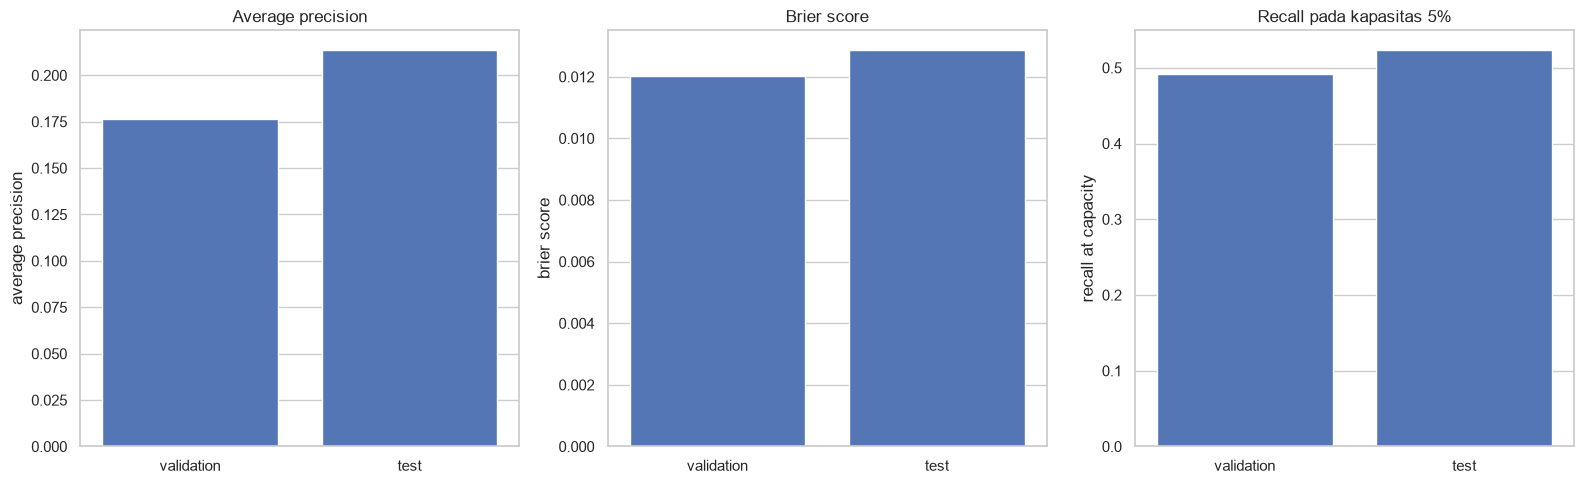

In [5]:
display(result.temporal_comparison.style.format(precision=6))

figure, axes = plt.subplots(1, 3, figsize=(16, 5))
for axis, metric, title in [
    (axes[0], "average_precision", "Average precision"),
    (axes[1], "brier_score", "Brier score"),
    (axes[2], "recall_at_capacity", "Recall pada kapasitas 5%"),
]:
    sns.barplot(
        data=result.temporal_comparison,
        x="split",
        y=metric,
        ax=axis,
        color="#4472C4",
    )
    axis.set_title(title)
    axis.set_xlabel("")
    axis.set_ylabel(metric.replace("_", " "))

figure.tight_layout()
plt.show()

## 5. Confidence interval test

Interval menggunakan stratified percentile bootstrap dengan jumlah resample dan random seed yang telah dikunci sebelum test.

,metric,point_estimate,ci_lower,ci_upper,confidence_level,number_of_resamples,method
0,average_precision,0.213467,0.197809,0.231484,0.950000,200,stratified_percentile
1,roc_auc,0.895401,0.886371,0.903805,0.950000,200,stratified_percentile
2,brier_score,0.012859,0.012692,0.013024,0.950000,200,stratified_percentile
3,precision_at_capacity,0.154243,0.145984,0.161068,0.950000,200,stratified_percentile
4,recall_at_capacity,0.523109,0.495098,0.546254,0.950000,200,stratified_percentile


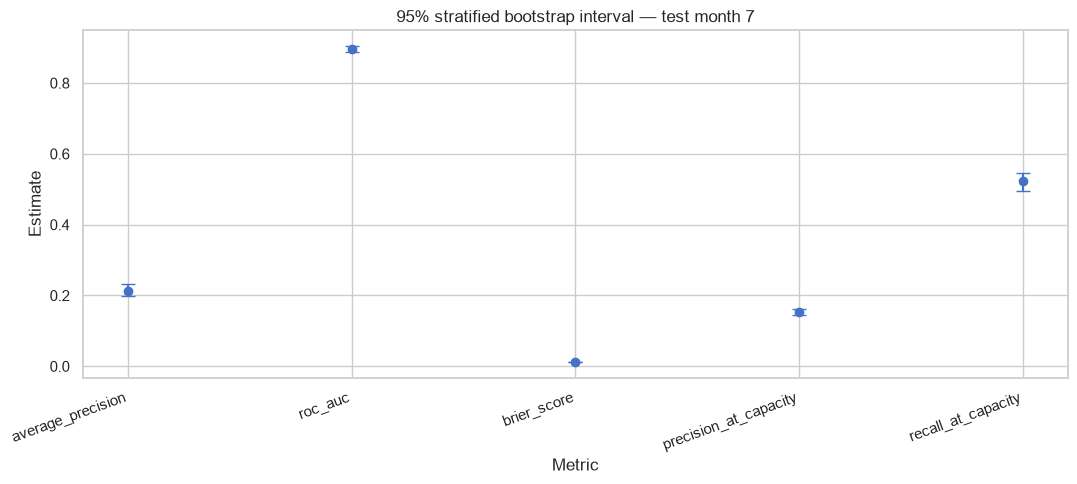

In [6]:
display(result.bootstrap_intervals.style.format(precision=6))

intervals = result.bootstrap_intervals.copy()
lower_error = intervals["point_estimate"] - intervals["ci_lower"]
upper_error = intervals["ci_upper"] - intervals["point_estimate"]
plt.figure(figsize=(11, 5))
plt.errorbar(
    intervals["metric"],
    intervals["point_estimate"],
    yerr=np.vstack([lower_error, upper_error]),
    fmt="o",
    capsize=5,
    color="#4472C4",
)
plt.title("95% stratified bootstrap interval — test month 7")
plt.xlabel("Metric")
plt.ylabel("Estimate")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 6. Transfer threshold dan exact capacity

Fixed threshold menerapkan cutoff numerik month 6 ke month 7 tanpa perubahan. Exact capacity menjaga beban antrean 5% berdasarkan ranking yang dikunci. Perbedaan keduanya menunjukkan dampak distribution shift pada cutoff.

In [7]:
review_policy_comparison = pd.DataFrame(
    [
        {
            "policy": result.fixed_threshold_metrics["policy"],
            "review_count": result.fixed_threshold_metrics["review_count"],
            "review_rate": result.fixed_threshold_metrics["review_rate"],
            "captured_fraud": result.fixed_threshold_metrics["true_positive"],
            "missed_fraud": result.fixed_threshold_metrics["false_negative"],
            "precision": result.fixed_threshold_metrics["precision"],
            "recall": result.fixed_threshold_metrics["recall"],
            "score_threshold": result.fixed_threshold_metrics["score_threshold"],
        },
        {
            "policy": result.capacity_metrics["policy"],
            "review_count": result.capacity_metrics["review_count"],
            "review_rate": result.capacity_metrics["review_rate"],
            "captured_fraud": result.capacity_metrics["true_positive"],
            "missed_fraud": result.capacity_metrics["false_negative"],
            "precision": result.capacity_metrics["precision"],
            "recall": result.capacity_metrics["recall"],
            "score_threshold": float("nan"),
        },
    ]
)
display(review_policy_comparison.style.format(precision=6))
assert result.capacity_metrics["review_count"] == int(
    np.ceil(result.metadata["test_rows"] * config["review_policy"]["capacity_rate"])
)

,policy,review_count,review_rate,captured_fraud,missed_fraud,precision,recall,score_threshold
0,fixed_validation_score_threshold,4233,0.043710,712,716,0.168202,0.498599,0.063432
1,exact_batch_capacity,4843,0.050009,747,681,0.154243,0.523109,nan


## 7. Risk band pada test

Cutoff risk band tetap berasal dari validation month 6. Row share pada test boleh berubah dan menjadi bagian dari stability diagnostic.

,risk_band,row_count,row_share,fraud_count,fraud_share,fraud_prevalence,minimum_probability,maximum_probability,mean_probability
0,sangat_tinggi,892,0.009211,289,0.202381,0.323991,0.203271,0.871553,0.335460
1,tinggi,3341,0.034499,423,0.296218,0.126609,0.063444,0.202975,0.108853
2,menengah,4248,0.043865,236,0.165266,0.055556,0.031135,0.063404,0.044012
3,rendah,88362,0.912425,480,0.336134,0.005432,0.000008,0.031110,0.004592


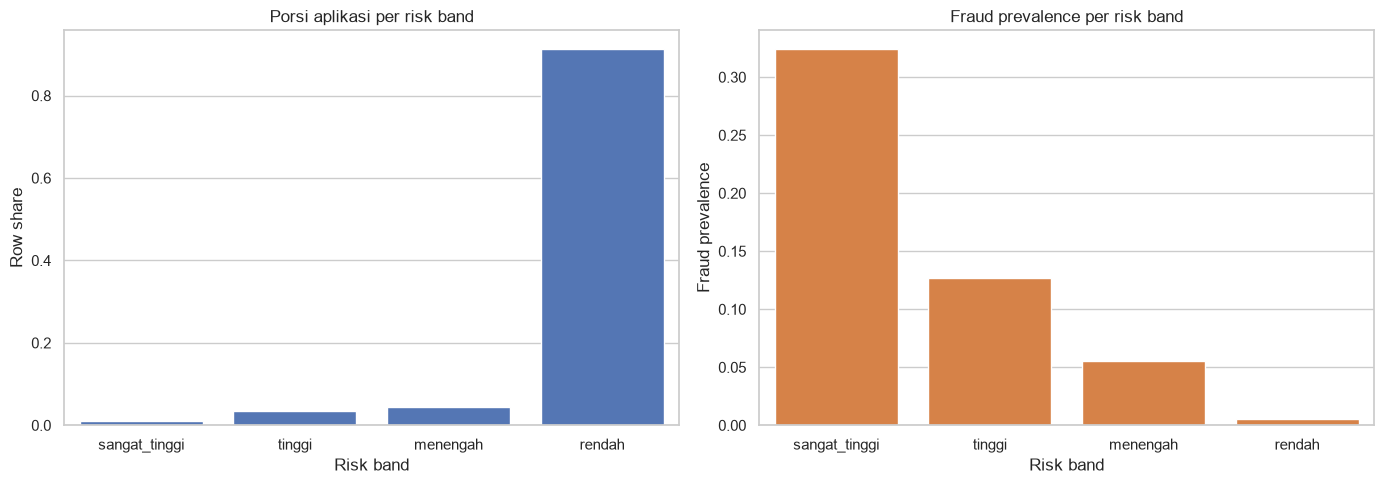

In [8]:
display(result.risk_band_summary.style.format(precision=6))

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=result.risk_band_summary,
    x="risk_band",
    y="row_share",
    ax=axes[0],
    color="#4472C4",
)
axes[0].set_title("Porsi aplikasi per risk band")
axes[0].set_xlabel("Risk band")
axes[0].set_ylabel("Row share")
sns.barplot(
    data=result.risk_band_summary,
    x="risk_band",
    y="fraud_prevalence",
    ax=axes[1],
    color="#ED7D31",
)
axes[1].set_title("Fraud prevalence per risk band")
axes[1].set_xlabel("Risk band")
axes[1].set_ylabel("Fraud prevalence")
figure.tight_layout()
plt.show()

## 8. Stability reporting alert

Alert diterapkan pada perubahan adverse validation-to-test. Alert tidak mengubah model dan hanya menghasilkan tindakan `report_and_investigate_only`.

In [9]:
display(result.stability_assessment.style.format(precision=6))
alert_count = int(result.stability_assessment["alert_triggered"].sum())
display(
    Markdown(
        f"**Reporting alert terpicu:** `{alert_count}` dari "
        f"`{len(result.stability_assessment)}` metrik. "
        "Tindakan tetap investigasi dan dokumentasi, bukan tuning ulang."
    )
)

,metric,validation_value,test_value,test_minus_validation,adverse_direction,maximum_allowed_adverse_change,alert_triggered,action
0,average_precision,0.176706,0.213467,0.036761,drop,0.030000,False,report_and_investigate_only
1,recall_at_capacity,0.491724,0.523109,0.031385,drop,0.050000,False,report_and_investigate_only
2,brier_score,0.012023,0.012859,0.000836,increase,0.005000,False,report_and_investigate_only
3,expected_calibration_error,0.000955,0.002036,0.001081,increase,0.020000,False,report_and_investigate_only


**Reporting alert terpicu:** `0` dari `4` metrik. Tindakan tetap investigasi dan dokumentasi, bukan tuning ulang.

## 9. Reliability diagram test

Plot membandingkan probabilitas mentah dan probabilitas terkalibrasi pada test. Perbandingan ini tidak memilih ulang calibrator.

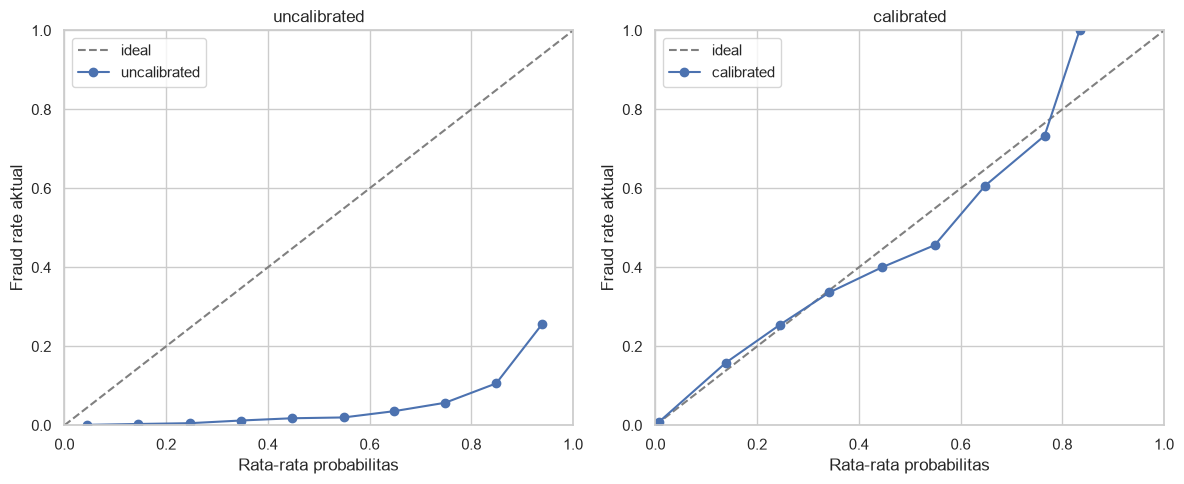

In [10]:
test_calibration_table = pd.read_csv(result.artifact_paths["calibration_table"])
methods = test_calibration_table["probability_method"].unique().tolist()
figure, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 5), squeeze=False)

for axis, method_name in zip(axes[0], methods, strict=True):
    method_table = test_calibration_table.loc[
        test_calibration_table["probability_method"].eq(method_name)
    ]
    axis.plot([0, 1], [0, 1], linestyle="--", color="gray", label="ideal")
    axis.plot(
        method_table["mean_predicted_probability"],
        method_table["observed_fraud_rate"],
        marker="o",
        label=method_name,
    )
    axis.set_title(method_name)
    axis.set_xlabel("Rata-rata probabilitas")
    axis.set_ylabel("Fraud rate aktual")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.legend()

figure.tight_layout()
plt.show()

## 10. Pre-registered slice diagnostic

Slice membantu menemukan konsentrasi failure mode. Slice yang tidak memenuhi minimum support tidak diberi AP atau ROC-AUC dan tidak boleh dipakai untuk klaim fairness.

In [11]:
slice_columns = [
    "slice_feature",
    "slice_value",
    "row_count",
    "fraud_count",
    "prevalence",
    "mean_probability",
    "calibration_gap",
    "average_precision",
    "roc_auc",
    "review_rate",
    "review_precision",
    "within_slice_fraud_capture",
    "eligible_for_discrimination_metrics",
]
display(result.slice_metrics.loc[:, slice_columns].style.format(precision=6))

largest_calibration_gaps = (
    result.slice_metrics.assign(
        absolute_calibration_gap=lambda frame: frame["calibration_gap"].abs()
    )
    .nlargest(15, "absolute_calibration_gap")
)
display(
    largest_calibration_gaps.loc[
        :,
        [
            "slice_feature",
            "slice_value",
            "row_count",
            "fraud_count",
            "calibration_gap",
            "absolute_calibration_gap",
        ],
    ].style.format(precision=6)
)

,slice_feature,slice_value,row_count,fraud_count,prevalence,mean_probability,calibration_gap,average_precision,roc_auc,review_rate,review_precision,within_slice_fraud_capture,eligible_for_discrimination_metrics
0,customer_age,"[0.0, 25.0)",23953,169,0.007055,0.005845,-0.001211,0.089423,0.860076,0.014737,0.127479,0.266272,True
1,customer_age,"[25.0, 35.0)",32363,405,0.012514,0.010292,-0.002222,0.167435,0.876889,0.037574,0.136513,0.409877,True
2,customer_age,"[35.0, 45.0)",27860,436,0.015650,0.014675,-0.000974,0.205166,0.904779,0.058794,0.152015,0.571101,True
3,customer_age,"[45.0, 55.0)",9725,256,0.026324,0.025905,-0.000419,0.278027,0.897452,0.113728,0.156420,0.675781,True
4,customer_age,"[55.0, 65.0)",2501,131,0.052379,0.041606,-0.010773,0.359103,0.872242,0.179128,0.200893,0.687023,True
5,customer_age,"[65.0, 200.0)",441,31,0.070295,0.040236,-0.030059,nan,nan,0.185941,0.292683,0.774194,False
6,device_os,linux,33609,246,0.007319,0.005666,-0.001654,0.125758,0.863822,0.016186,0.128676,0.284553,True
7,device_os,macintosh,4932,97,0.019667,0.014549,-0.005119,0.228687,0.890869,0.054947,0.177122,0.494845,True
8,device_os,other,32734,251,0.007668,0.006924,-0.000744,0.079886,0.867696,0.021018,0.106105,0.290837,True
9,device_os,windows,25142,824,0.032774,0.030281,-0.002493,0.278240,0.880719,0.131931,0.166114,0.668689,True


,slice_feature,slice_value,row_count,fraud_count,calibration_gap,absolute_calibration_gap
17,employment_status,CG,38,2,-0.042108,0.042108
5,customer_age,"[65.0, 200.0)",441,31,-0.030059,0.030059
34,source,TELEAPP,378,14,-0.019848,0.019848
32,payment_type,AE,29,0,0.014667,0.014667
4,customer_age,"[55.0, 65.0)",2501,131,-0.010773,0.010773
10,device_os,x11,426,10,-0.010546,0.010546
13,employment_status,CC,2265,84,-0.009712,0.009712
7,device_os,macintosh,4932,97,-0.005119,0.005119
31,payment_type,AD,10630,177,-0.004991,0.004991
18,housing_status,BA,19182,899,-0.004785,0.004785


## 11. Error analysis exact-capacity

Contoh mencakup reviewed non-fraud, missed fraud yang dekat batas antrean, dan missed fraud dengan score terendah. Hasil tidak digunakan untuk memodifikasi kandidat final.

In [12]:
error_counts = result.error_analysis["error_type"].value_counts().rename("rows")
display(error_counts.to_frame())
error_columns = [
    "source_index",
    "target",
    "fraud_probability",
    "review_recommended",
    "error_type",
    "income",
    "customer_age",
    "payment_type",
    "employment_status",
    "housing_status",
    "source",
]
available_error_columns = [
    column for column in error_columns if column in result.error_analysis.columns
]
display(result.error_analysis.loc[:, available_error_columns])

,rows
error_type,
reviewed_non_fraud,25
missed_fraud_near_boundary,25
missed_fraud_low_score,25


,source_index,target,fraud_probability,review_recommended,error_type,income,customer_age,payment_type,employment_status,housing_status,source
0,53917,0,0.774470,1,reviewed_non_fraud,0.9,40,AB,CA,BA,INTERNET
1,41517,0,0.774047,1,reviewed_non_fraud,0.9,60,AC,CA,BC,INTERNET
2,73919,0,0.756477,1,reviewed_non_fraud,0.9,50,AB,CA,BA,INTERNET
3,79113,0,0.736822,1,reviewed_non_fraud,0.9,30,AC,CA,BA,INTERNET
4,14365,0,0.690215,1,reviewed_non_fraud,0.9,40,AB,CA,BA,INTERNET
...,...,...,...,...,...,...,...,...,...,...,...
70,62,1,0.000884,0,missed_fraud_low_score,0.1,30,AA,CD,BC,INTERNET
71,615,1,0.000895,0,missed_fraud_low_score,0.6,40,AB,CF,BC,INTERNET
72,591,1,0.000935,0,missed_fraud_low_score,0.8,20,AB,CF,BB,INTERNET
73,519,1,0.000954,0,missed_fraud_low_score,0.7,10,AB,CC,BC,INTERNET


## 12. Audit completion, artifact, dan governance

Completion ditulis terakhir. Assertion gagal tertutup jika test evaluation count bukan satu atau jika ada refit, recalibration, threshold reselection, maupun automated rejection.

In [13]:
freeze_manifest = json.loads(
    result.artifact_paths["freeze_manifest"].read_text(encoding="utf-8")
)
completion = json.loads(
    result.artifact_paths["completion"].read_text(encoding="utf-8")
)
artifact_table = pd.DataFrame(
    [
        {"artifact": name, "path": str(path)}
        for name, path in result.artifact_paths.items()
    ]
)
guardrails = {
    "freeze_status": freeze_manifest["status"],
    "freeze_test_evaluated": freeze_manifest["test_evaluated"],
    "completion_status": completion["status"],
    "test_evaluated": result.metadata["test_evaluated"],
    "test_evaluation_count": result.metadata["test_evaluation_count"],
    "base_model_refit_after_test": result.metadata["base_model_refit_after_test"],
    "calibrator_refit_after_test": result.metadata["calibrator_refit_after_test"],
    "threshold_reselected_after_test": result.metadata["threshold_reselected_after_test"],
    "risk_bands_reselected_after_test": result.metadata["risk_bands_reselected_after_test"],
    "test_used_for": result.metadata["test_used_for"],
    "automated_rejection_allowed": result.metadata["automated_rejection_allowed"],
}

assert freeze_manifest["test_evaluated"] is False
assert completion["status"] == "completed"
assert completion["test_evaluation_count"] == 1
assert result.metadata["test_evaluated"] is True
assert result.metadata["test_evaluation_count"] == 1
assert result.metadata["base_model_refit_after_test"] is False
assert result.metadata["calibrator_refit_after_test"] is False
assert result.metadata["threshold_reselected_after_test"] is False
assert result.metadata["risk_bands_reselected_after_test"] is False
assert result.metadata["automated_rejection_allowed"] is False
assert not hasattr(result, "test_features")
assert not hasattr(result, "test_target")

display(artifact_table)
display(pd.Series(guardrails, name="nilai").to_frame())

,artifact,path
0,freeze_manifest,D:\latihan\fraudshield\artifacts\phase6\freeze...
1,evaluation_state,D:\latihan\fraudshield\artifacts\phase6\evalua...
2,completion,D:\latihan\fraudshield\artifacts\phase6\final_...
3,test_metrics,D:\latihan\fraudshield\artifacts\phase6\final_...
4,fixed_threshold_metrics,D:\latihan\fraudshield\artifacts\phase6\fixed_...
5,capacity_metrics,D:\latihan\fraudshield\artifacts\phase6\capaci...
6,bootstrap_intervals,D:\latihan\fraudshield\artifacts\phase6\bootst...
7,temporal_comparison,D:\latihan\fraudshield\artifacts\phase6\valida...
8,stability_assessment,D:\latihan\fraudshield\artifacts\phase6\stabil...
9,risk_band_summary,D:\latihan\fraudshield\artifacts\phase6\test_r...


,nilai
freeze_status,prepared
freeze_test_evaluated,False
completion_status,completed
test_evaluated,True
test_evaluation_count,1
base_model_refit_after_test,False
calibrator_refit_after_test,False
threshold_reselected_after_test,False
risk_bands_reselected_after_test,False
test_used_for,one_time_final_reporting_only


## 13. Ringkasan final terhitung

Cell ini menyusun ringkasan langsung dari artifact hasil pertama. Tidak ada angka test yang ditulis manual.

In [14]:
test_calibrated = result.test_metrics["calibrated"]
validation_row = result.temporal_comparison.loc[
    result.temporal_comparison["split"].eq("validation")
].iloc[0]
display(
    Markdown(
        f"Test month 7 berisi **{test_calibrated['row_count']:,}** aplikasi "
        f"dengan prevalence **{test_calibrated['prevalence']:.4%}**. "
        f"Average precision test adalah **{test_calibrated['pr_auc_average_precision']:.6f}** "
        f"dibanding **{validation_row['average_precision']:.6f}** pada validation. "
        f"ROC-AUC test **{test_calibrated['roc_auc']:.6f}**, Brier score "
        f"**{test_calibrated['brier_score']:.6f}**, dan ECE "
        f"**{test_calibrated['expected_calibration_error']:.6f}**.  \
"
        f"Exact capacity 5% mereview **{result.capacity_metrics['review_count']:,}** "
        f"aplikasi, menangkap **{result.capacity_metrics['true_positive']:,}** fraud, "
        f"dengan precision **{result.capacity_metrics['precision']:.6f}** dan "
        f"recall **{result.capacity_metrics['recall']:.6f}**. "
        f"Reporting alert terpicu: **{alert_count}**. Test evaluation count tetap **1**."
    )
)

Test month 7 berisi **96,843** aplikasi dengan prevalence **1.4746%**. Average precision test adalah **0.213467** dibanding **0.176706** pada validation. ROC-AUC test **0.895401**, Brier score **0.012859**, dan ECE **0.002036**.  Exact capacity 5% mereview **4,843** aplikasi, menangkap **747** fraud, dengan precision **0.154243** dan recall **0.523109**. Reporting alert terpicu: **0**. Test evaluation count tetap **1**.

## Kesimpulan Fase 6

Fase 6 menyelesaikan evaluasi temporal final dengan model, calibrator, threshold, dan risk band yang telah dibekukan sebelum month 7 dibuka. Seluruh hasil disimpan dengan hash dan completion record; Run All berikutnya hanya memuat hasil tersebut tanpa mengevaluasi test ulang.

Hasil test merupakan bukti generalisasi kandidat final pada satu periode sintetis, bukan persetujuan produksi. Reporting alert dan error analysis hanya boleh digunakan untuk dokumentasi serta perencanaan generasi model berikutnya. Score dan risk band tetap merupakan bantuan prioritas human review, bukan keputusan otomatis.